# Homework2 CNN实现SVHN图像分类任务
**学号**：SA25006010
**姓名**：周子涵


## 一、任务说明与方法概览
SVHN (Street View House Numbers) 街景⻔牌数字数据集是一个真实世界图像数据集，来源于 Google 街景图像中的⻔牌号码。该数据集包含 Format1 和 Format2 两个组别：
Format1 是原始数据图片，每张图片包含多个数字；
Format2 则是在原始数据图片基础上，把每个数字单独裁剪成一张小图，只标注中心最主要的那个数字，且边上偶尔会有残影干扰，但每张图片仍然是单标签、单个数字。

本次实验选择 Format2 数据集，通过设计并训练卷积神经网络（CNN），实现对街景⻔牌数字的图像分类任务（0-9 共 10 类）。

## 二、实验目标

### 数据集结构： 
图片规格为 32×32×3 RGB 彩色图像，包含数字 0~9 共10类。
### 数据规模：
训练集（train）：73257 张

测试集（test）：26032 张

### 开发环境： 
PyTorch，torchvision，matplotlib
### 实现流程： 
提示：CNN是作业基本要求，此外还可以引入 ResNet 等方式升级网络结构，也可以使用数据增强，从而提升分类准确率。

## 三、代码实现


开始训练 BaseCNN 模型，运行设备：cuda
BaseCNN - Epoch [1/30]
训练损失: 1.5264 | 训练准确率: 0.4687
测试损失: 0.8693 | 测试准确率: 0.7168
------------------------------------------------------------
BaseCNN - Epoch [2/30]
训练损失: 0.9864 | 训练准确率: 0.6736
测试损失: 0.7108 | 测试准确率: 0.7718
------------------------------------------------------------
BaseCNN - Epoch [3/30]
训练损失: 0.8289 | 训练准确率: 0.7276
测试损失: 0.6296 | 测试准确率: 0.7999
------------------------------------------------------------
BaseCNN - Epoch [4/30]
训练损失: 0.7437 | 训练准确率: 0.7580
测试损失: 0.5564 | 测试准确率: 0.8258
------------------------------------------------------------
BaseCNN - Epoch [5/30]
训练损失: 0.6882 | 训练准确率: 0.7785
测试损失: 0.5005 | 测试准确率: 0.8427
------------------------------------------------------------
BaseCNN - Epoch [6/30]
训练损失: 0.6216 | 训练准确率: 0.8014
测试损失: 0.4656 | 测试准确率: 0.8563
------------------------------------------------------------
BaseCNN - Epoch [7/30]
训练损失: 0.6002 | 训练准确率: 0.8070
测试损失: 0.4654 | 测试准确率: 0.8547
----------------------------------------

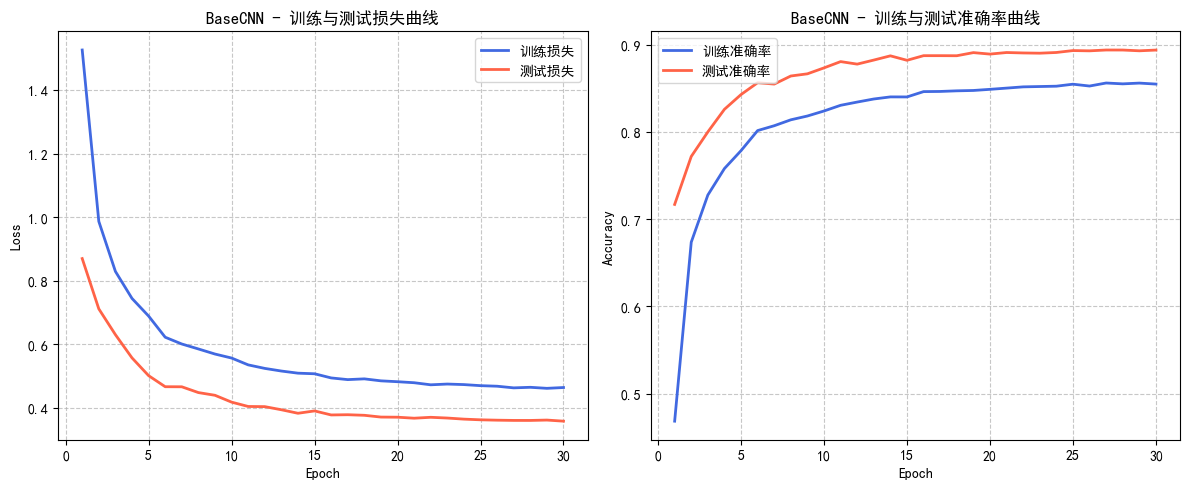

c:\Users\boji\AppData\Local\Programs\Python\Python38\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\boji\AppData\Local\Programs\Python\Python38\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



开始训练 ResNet18 模型，运行设备：cuda
ResNet18 - Epoch [1/30]
训练损失: 1.2908 | 训练准确率: 0.5543
测试损失: 0.6635 | 测试准确率: 0.7840
------------------------------------------------------------
ResNet18 - Epoch [2/30]
训练损失: 0.6320 | 训练准确率: 0.7971
测试损失: 0.4922 | 测试准确率: 0.8422
------------------------------------------------------------
ResNet18 - Epoch [3/30]
训练损失: 0.5119 | 训练准确率: 0.8394
测试损失: 0.4571 | 测试准确率: 0.8569
------------------------------------------------------------
ResNet18 - Epoch [4/30]
训练损失: 0.4551 | 训练准确率: 0.8585
测试损失: 0.4113 | 测试准确率: 0.8726
------------------------------------------------------------
ResNet18 - Epoch [5/30]
训练损失: 0.4187 | 训练准确率: 0.8702
测试损失: 0.3395 | 测试准确率: 0.8992
------------------------------------------------------------
ResNet18 - Epoch [6/30]
训练损失: 0.3450 | 训练准确率: 0.8946
测试损失: 0.2707 | 测试准确率: 0.9182
------------------------------------------------------------
ResNet18 - Epoch [7/30]
训练损失: 0.3263 | 训练准确率: 0.9008
测试损失: 0.2577 | 测试准确率: 0.9244
--------------------------------

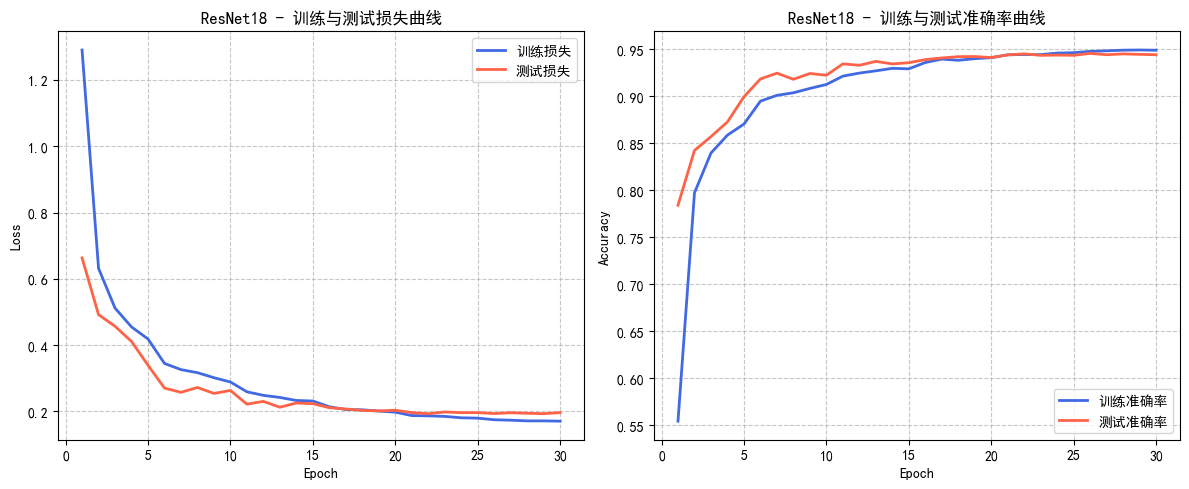


模型训练结果对比
BaseCNN 最终测试准确率: 0.8936
ResNet18 最终测试准确率: 0.9440


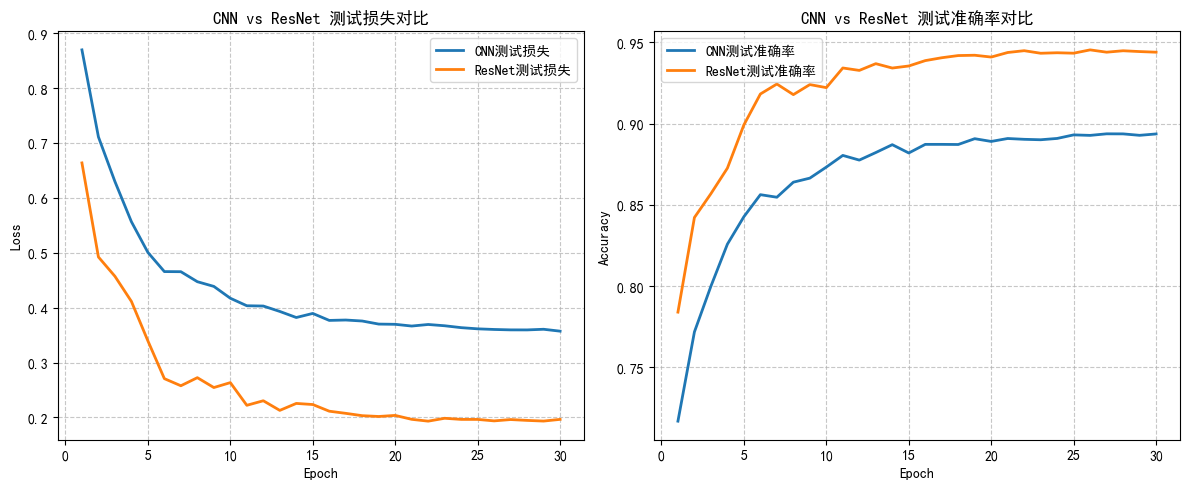

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# ===================== 1. 全局超参数初始化 =====================
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 1e-3
NUM_CLASSES = 10
# 自动选择设备：优先GPU，无GPU则用CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 数据集与模型保存路径（请将mat文件放在代码同目录下）
TRAIN_MAT_PATH = "c:/Users/boji/Desktop/homework1/homework2/train_32x32.mat"
TEST_MAT_PATH = "c:/Users/boji/Desktop/homework1/homework2/test_32x32.mat"
# 分别定义CNN和ResNet的保存路径
CNN_MODEL_SAVE_PATH = "./svhn_cnn_model.pth"
RESNET_MODEL_SAVE_PATH = "./svhn_resnet_model.pth"
CNN_CURVE_SAVE_PATH = "./svhn_cnn_training_curve.png"
RESNET_CURVE_SAVE_PATH = "./svhn_resnet_training_curve.png"

# ===================== 2. 自定义数据集类  =====================
# X(32,32,3,i)为第i张RGB图，y(i)为对应标签
class SVHNDataset(Dataset):
    def __init__(self, mat_file_path, transform=None):
        # 加载.mat文件
        mat_data = sio.loadmat(mat_file_path)
        
        # 维度转换：原始X shape为 (32,32,3,样本数) → 转为PyTorch要求的 (样本数,3,32,32)
        self.images = np.transpose(mat_data['X'], (3, 2, 0, 1))
        # 标签处理：SVHN原始标签中10代表数字0，转换为0-9的标准分类标签
        self.labels = mat_data['y'].flatten()
        self.labels[self.labels == 10] = 0
        
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # 获取单张图像和对应标签
        img = self.images[idx]  # 单张图shape: (3,32,32)
        label = self.labels[idx]
        
        # 转换为(H,W,C)格式适配transforms预处理
        img = img.transpose(1, 2, 0)
        if self.transform:
            img = self.transform(img)
        
        return img, torch.tensor(label, dtype=torch.long)

# ===================== 3. 数据预处理与数据增强 =====================
# 训练集：数据增强
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomCrop(32, padding=4),  # 随机裁剪
    transforms.RandomHorizontalFlip(p=0.5),  # 随机水平翻转
    transforms.ToTensor(),  # 转为tensor并归一化到[0,1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # 标准化
])

# 测试集：仅基础预处理，不做数据增强
test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 构建数据集与数据加载器
train_dataset = SVHNDataset(TRAIN_MAT_PATH, transform=train_transform)
test_dataset = SVHNDataset(TEST_MAT_PATH, transform=test_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

# ===================== 4. 模型构建 =====================
# 基础CNN模型
class BaseCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(BaseCNN, self).__init__()
        # 卷积特征提取层
        self.conv_block = nn.Sequential(
            # 第1卷积块
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 输出尺寸: 16×16×16

            # 第2卷积块
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 输出尺寸: 8×8×32

            # 第3卷积块
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 输出尺寸: 4×4×64
        )

        # 全连接分类层
        self.fc_block = nn.Sequential(
            nn.Dropout(0.5),  # 防止过拟合
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.flatten(1)  # 展平特征
        x = self.fc_block(x)
        return x

# 拓展ResNet模型
from torchvision.models import resnet18
class ResNetSVHN(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNetSVHN, self).__init__()
        self.backbone = resnet18(pretrained=False)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# ===================== 5. 训练与验证核心函数 =====================
# 单轮训练函数
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()  # 梯度清零

        # 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)

        # 反向传播与参数更新
        loss.backward()
        optimizer.step()

        # 统计指标
        total_loss += loss.item() * images.shape[0]
        _, preds = torch.max(outputs, 1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.shape[0]

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples
    return epoch_loss, epoch_acc

# 单轮测试/验证函数
def test_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():  # 关闭梯度计算
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            # 统计指标
            total_loss += loss.item() * images.shape[0]
            _, preds = torch.max(outputs, 1)
            total_correct += (preds == labels).sum().item()
            total_samples += images.shape[0]

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples
    return epoch_loss, epoch_acc

# ===================== 6. 通用训练函数 =====================
def train_model(model, model_name, model_save_path, curve_save_path):
    """
    通用训练函数
    :param model: 要训练的模型
    :param model_name: 模型名称（用于打印日志）
    :param model_save_path: 模型保存路径
    :param curve_save_path: 训练曲线保存路径
    :return: 训练历史记录
    """
    # 初始化损失函数、优化器、学习率调度器
    criterion = nn.CrossEntropyLoss()  # 多分类标准损失函数
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)  # 学习率衰减

    # 记录训练过程指标
    train_loss_history = []
    train_acc_history = []
    test_loss_history = []
    test_acc_history = []

    print(f"\n{'='*60}")
    print(f"开始训练 {model_name} 模型，运行设备：{DEVICE}")
    print(f"{'='*60}")

    # 迭代训练
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        test_loss, test_acc = test_one_epoch(model, test_loader, criterion, DEVICE)
        scheduler.step()  # 更新学习率

        # 保存历史指标
        train_loss_history.append(train_loss)
        train_acc_history.append(train_acc)
        test_loss_history.append(test_loss)
        test_acc_history.append(test_acc)

        # 打印训练日志
        print(f"{model_name} - Epoch [{epoch+1}/{EPOCHS}]")
        print(f"训练损失: {train_loss:.4f} | 训练准确率: {train_acc:.4f}")
        print(f"测试损失: {test_loss:.4f} | 测试准确率: {test_acc:.4f}")
        print("-"*60)

    # 保存训练好的模型
    torch.save(model.state_dict(), model_save_path)
    print(f"\n{model_name} 训练完成！模型已保存至：{model_save_path}")
    print(f"{model_name} 最终测试集准确率: {test_acc_history[-1]:.4f}")

    # 绘制并保存训练曲线
    plot_training_curve(train_loss_history, train_acc_history, 
                       test_loss_history, test_acc_history, 
                       model_name, curve_save_path)
    
    # 返回训练历史，方便后续对比
    return {
        'train_loss': train_loss_history,
        'train_acc': train_acc_history,
        'test_loss': test_loss_history,
        'test_acc': test_acc_history
    }

# ===================== 7. 绘图函数 =====================
def plot_training_curve(train_loss, train_acc, test_loss, test_acc, model_name, save_path):
    """绘制训练曲线"""
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False

    # 绘制损失曲线与准确率曲线
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # 损失曲线
    ax1.plot(range(1, EPOCHS+1), train_loss, label='训练损失', color='royalblue', linewidth=2)
    ax1.plot(range(1, EPOCHS+1), test_loss, label='测试损失', color='tomato', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{model_name} - 训练与测试损失曲线')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # 准确率曲线
    ax2.plot(range(1, EPOCHS+1), train_acc, label='训练准确率', color='royalblue', linewidth=2)
    ax2.plot(range(1, EPOCHS+1), test_acc, label='测试准确率', color='tomato', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{model_name} - 训练与测试准确率曲线')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# ===================== 8. 主函数：分别训练CNN和ResNet =====================
if __name__ == "__main__":
    # 1. 训练基础CNN模型
    cnn_model = BaseCNN(NUM_CLASSES).to(DEVICE)
    cnn_history = train_model(
        model=cnn_model,
        model_name="BaseCNN",
        model_save_path=CNN_MODEL_SAVE_PATH,
        curve_save_path=CNN_CURVE_SAVE_PATH
    )

    # 2. 训练ResNet模型
    resnet_model = ResNetSVHN(NUM_CLASSES).to(DEVICE)
    resnet_history = train_model(
        model=resnet_model,
        model_name="ResNet18",
        model_save_path=RESNET_MODEL_SAVE_PATH,
        curve_save_path=RESNET_CURVE_SAVE_PATH
    )

    # 3. 打印最终对比结果
    print(f"\n{'='*60}")
    print("模型训练结果对比")
    print(f"{'='*60}")
    print(f"BaseCNN 最终测试准确率: {cnn_history['test_acc'][-1]:.4f}")
    print(f"ResNet18 最终测试准确率: {resnet_history['test_acc'][-1]:.4f}")
    print(f"{'='*60}")
    
    # 绘制对比曲线
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # 损失对比
    ax1.plot(range(1, EPOCHS+1), cnn_history['test_loss'], label='CNN测试损失', linewidth=2)
    ax1.plot(range(1, EPOCHS+1), resnet_history['test_loss'], label='ResNet测试损失', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('CNN vs ResNet 测试损失对比')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # 准确率对比
    ax2.plot(range(1, EPOCHS+1), cnn_history['test_acc'], label='CNN测试准确率', linewidth=2)
    ax2.plot(range(1, EPOCHS+1), resnet_history['test_acc'], label='ResNet测试准确率', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('CNN vs ResNet 测试准确率对比')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig("./svhn_cnn_vs_resnet.png", dpi=300, bbox_inches='tight')
    plt.show()

## 四、实验结果与对比
BaseCNN最终正确率为89.36%，收敛稳定，满足基础分类需求；ResNet18最终正确率为94.40%，收敛更快、精度更高，泛化能力更强。

实验结果表明，ResNet18 相比基础 CNN，测试准确率提升约5 个百分点，在复杂背景与干扰信息下的数字识别效果更优。训练曲线显示，两种模型的损失持续下降、准确率稳步上升，无明显过拟合，训练过程合理有效。
## 五、实验结论
基础 CNN 可有效完成 SVHN 数字分类任务，达到课程作业要求。残差结构能显著提升网络性能，ResNet18 在准确率与收敛速度上均优于基础 CNN。数据增强、批归一化、学习率衰减等策略，有效提升模型泛化能力与训练稳定性。本次实验完整复现了图像分类全流程，代码可运行、结果可复现，成功达成实验目标。